# Assignment #1

**Janin Jankovski, Florian Robrecht, Anna Hartmann**

---

## Datasets

**Dataset 1:** Kaggle Pokémon Dataset
https://www.kaggle.com/datasets/rounakbanik/pokemon/

**Dataset 2:** Fashion-MNIST (Zalando Research)
https://www.kaggle.com/datasets/zalando-research/fashionmnist

---

## Introduction

We use two datasets to study how sparse random projections behave across fundamentally different types of data: a low-dimensional tabular dataset with engineered features (Pokémon) and a higher-dimensional image dataset with raw pixel features (Fashion-MNIST).

The **Pokémon dataset** consists of engineered attributes such as type-matchup multipliers, base stats, and categorical flags. These features do not live in a natural geometric space — Euclidean distance between two Pokémon vectors has no obvious physical meaning, and many features are correlated or partially redundant (e.g. type interactions with one-hot encoded types). The task is binary classification: predict whether a Pokémon is legendary. Legendary Pokémon are rare, powerful entities within the Pokémon universe, typically unique, non-evolving, and tied to specific in-game events or lore — which also makes the dataset strongly class-imbalanced (~9% legendary).

The **Fashion-MNIST dataset** consists of 28×28 grayscale images of clothing items across 10 classes, represented as 784-dimensional pixel-intensity vectors. Unlike the Pokémon features, these vectors live in a genuine Euclidean space: pairwise distances reflect visual similarity, and the data is known to concentrate on a lower-dimensional manifold within the ambient 784-dimensional space. This makes it a natural setting for random projections, which the Johnson–Lindenstrauss lemma guarantees will approximately preserve pairwise distances.

In [49]:
# import general libraries
import pandas as pd
import kagglehub
import os
import numpy as np
import matplotlib.pyplot as plt

# import sklearn libraries 
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.random_projection import SparseRandomProjection, johnson_lindenstrauss_min_dim
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score 

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [50]:
# Shared helper functions for random projection experiments

def make_dims(max_dim, n_points=20):
    """Log-spaced dimensions: denser at low k, sparser at high k."""
    return np.unique(np.geomspace(2, max_dim, n_points).astype(int))


def run_rp_experiment(X_train, X_test, y_train, y_test, dims,
                      realizations=15, max_iter=2000, f1_avg='binary'):
    """Run sparse random projection + LinearSVC for each dimension,
    repeated over multiple realizations."""
    acc_all    = np.zeros((realizations, len(dims)))
    f1_all     = np.zeros((realizations, len(dims)))
    recall_all = np.zeros((realizations, len(dims)))

    for j, dim in enumerate(dims):
        for i in range(realizations):
            rp = SparseRandomProjection(n_components=dim, random_state=i)
            X_train_rp = rp.fit_transform(X_train)
            X_test_rp  = rp.transform(X_test)

            model = LinearSVC(max_iter=max_iter, random_state=42)
            model.fit(X_train_rp, y_train)
            y_pred = model.predict(X_test_rp)

            acc_all[i, j]    = accuracy_score(y_test, y_pred)
            f1_all[i, j]     = f1_score(y_test, y_pred, average=f1_avg, zero_division=0)
            recall_all[i, j] = recall_score(y_test, y_pred, average=f1_avg, zero_division=0)

        print(f"  k={dim:4d}:  acc = {acc_all[:, j].mean():.4f} +/- {acc_all[:, j].std():.4f}  |  "
              f"F1 = {f1_all[:, j].mean():.4f} +/- {f1_all[:, j].std():.4f}  |  "
              f"Recall = {recall_all[:, j].mean():.4f} +/- {recall_all[:, j].std():.4f}")

    return {
        'mean_acc':    acc_all.mean(axis=0),    'std_acc':    acc_all.std(axis=0),
        'mean_f1':     f1_all.mean(axis=0),     'std_f1':     f1_all.std(axis=0),
        'mean_recall': recall_all.mean(axis=0), 'std_recall': recall_all.std(axis=0),
        'acc_all':    acc_all,
        'f1_all':     f1_all,
        'recall_all': recall_all,
    }


def plot_rp_results(dims, results, baseline_acc, baseline_f1, title, realizations,
                    ensemble_sizes=None, baseline_recall=None):
    """Standard 4-panel plot: accuracy, F1, variability, recall-vs-dim with
    multiple ensemble sizes overlaid."""
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Accuracy
    axes[0, 0].plot(dims, results['mean_acc'], 'b-o', markersize=4, label='RP mean accuracy')
    axes[0, 0].fill_between(dims, results['mean_acc'] - results['std_acc'],
                            results['mean_acc'] + results['std_acc'], alpha=0.2)
    axes[0, 0].axhline(baseline_acc, color='r', linestyle='--', label=f'Baseline: {baseline_acc:.3f}')
    axes[0, 0].set(xlabel='Projected dimensions k', ylabel='Accuracy',
                   title=f'{title}: Accuracy vs. Dimension')
    axes[0, 0].set_ylim(0, 1)
    axes[0, 0].legend()

    # F1-score
    axes[0, 1].plot(dims, results['mean_f1'], 'g-o', markersize=4, label='RP mean F1')
    axes[0, 1].fill_between(dims, results['mean_f1'] - results['std_f1'],
                            results['mean_f1'] + results['std_f1'], alpha=0.2, color='g')
    axes[0, 1].axhline(baseline_f1, color='r', linestyle='--', label=f'Baseline: {baseline_f1:.3f}')
    axes[0, 1].set(xlabel='Projected dimensions k', ylabel='F1-score',
                   title=f'{title}: F1-score vs. Dimension')
    axes[0, 1].set_ylim(0, 1)
    axes[0, 1].legend()

    # Variability
    axes[1, 0].plot(dims, results['std_acc'], 'b-o', markersize=4, label='Accuracy std')
    axes[1, 0].plot(dims, results['std_f1'], 'g-o', markersize=4, label='F1 std')
    axes[1, 0].set(xlabel='Projected dimensions k', ylabel='Standard deviation',
                   title=f'{title}: Metric Variability across Projections')
    axes[1, 0].legend()

    # Recall vs. Dimension — one curve per ensemble size to show how averaging
    # more random realizations smooths the recall curve.
    recall_all = results['recall_all']
    if ensemble_sizes is None:
        ensemble_sizes = [1, realizations]
    ensemble_sizes = [min(n, recall_all.shape[0]) for n in ensemble_sizes]
    colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(ensemble_sizes)))

    for color, n in zip(colors, ensemble_sizes):
        mean_n = recall_all[:n].mean(axis=0)
        label = f'{n} run' if n == 1 else f'{n} runs'
        lw = 1.0 if n == 1 else 2.0
        alpha = 0.7 if n == 1 else 1.0
        axes[1, 1].plot(dims, mean_n, color=color, linewidth=lw, alpha=alpha, label=label)

    if baseline_recall is not None:
        axes[1, 1].axhline(baseline_recall, color='r', linestyle='--',
                           label=f'Baseline: {baseline_recall:.3f}')
    axes[1, 1].set(xlabel='Projected dimensions k', ylabel='Recall',
                   title=f'{title}: Recall vs. Dimension')
    axes[1, 1].set_ylim(0, 1)
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()


## 1. Pokémon Dataset

**Dataset:**
- **Kaggle Pokémon Dataset**: 801 Pokémon with 41 features (base stats, type-matchup multipliers, categorical types, physical attributes)

The target is binary classification (`is_legendary`). Unlike image data, these features are heterogeneous — a mix of engineered numeric attributes, one-hot encoded categoricals, and type multipliers — so the feature space does not correspond to a natural Euclidean geometry.

### Load and Explore

We load the Pokémon dataset from Kaggle. Each row describes one Pokémon with its stats, type matchups, and categorical attributes. We inspect the shape, data types, and missing values, then visualize a few stat relationships to see how legendary Pokémon (red) separate from the rest.

In [51]:
# load pokemon dataset
path = kagglehub.dataset_download("rounakbanik/pokemon")
df = pd.read_csv(os.path.join(path, "pokemon.csv"))

In [52]:
# Exploratory Data Analysis (EDA)

# First look
pd.set_option('display.max_columns', None)
display(df.head())
pd.reset_option('display.max_columns')

# Check size 
display(df.shape)

# Columns
display(df.columns)

# Data types
display(df.info())

# Missing values in %
display((df.isna().sum() / len(df)) * 100)

,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,against_grass,against_ground,against_ice,against_normal,against_poison,against_psychic,against_rock,against_steel,against_water,attack,base_egg_steps,base_happiness,base_total,capture_rate,classfication,defense,experience_growth,height_m,hp,japanese_name,name,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
0,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,1.0,2.0,1.0,1.0,2.0,1.0,1.0,0.5,49,5120,70,318,45,Seed Pokémon,49,1059860,0.7,45,Fushigidaneフシギダネ,Bulbasaur,88.1,1,65,65,45,grass,poison,6.9,1,0
1,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,1.0,2.0,1.0,1.0,2.0,1.0,1.0,0.5,62,5120,70,405,45,Seed Pokémon,63,1059860,1.0,60,Fushigisouフシギソウ,Ivysaur,88.1,2,80,80,60,grass,poison,13.0,1,0
2,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,1.0,2.0,1.0,1.0,2.0,1.0,1.0,0.5,100,5120,70,625,45,Seed Pokémon,123,1059860,2.0,80,Fushigibanaフシギバナ,Venusaur,88.1,3,122,120,80,grass,poison,100.0,1,0
3,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,0.50,2.0,0.5,1.0,1.0,1.0,2.0,0.5,2.0,52,5120,70,309,45,Lizard Pokémon,43,1059860,0.6,39,Hitokageヒトカゲ,Charmander,88.1,4,60,50,65,fire,NaN,8.5,1,0
4,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,0.50,2.0,0.5,1.0,1.0,1.0,2.0,0.5,2.0,64,5120,70,405,45,Flame Pokémon,58,1059860,1.1,58,Lizardoリザード,Charmeleon,88.1,5,80,65,80,fire,NaN,19.0,1,0


(801, 41)

Index(['abilities', 'against_bug', 'against_dark', 'against_dragon',
       'against_electric', 'against_fairy', 'against_fight', 'against_fire',
       'against_flying', 'against_ghost', 'against_grass', 'against_ground',
       'against_ice', 'against_normal', 'against_poison', 'against_psychic',
       'against_rock', 'against_steel', 'against_water', 'attack',
       'base_egg_steps', 'base_happiness', 'base_total', 'capture_rate',
       'classfication', 'defense', 'experience_growth', 'height_m', 'hp',
       'japanese_name', 'name', 'percentage_male', 'pokedex_number',
       'sp_attack', 'sp_defense', 'speed', 'type1', 'type2', 'weight_kg',
       'generation', 'is_legendary'],
      dtype='str')

<class 'pandas.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 41 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   abilities          801 non-null    str    
 1   against_bug        801 non-null    float64
 2   against_dark       801 non-null    float64
 3   against_dragon     801 non-null    float64
 4   against_electric   801 non-null    float64
 5   against_fairy      801 non-null    float64
 6   against_fight      801 non-null    float64
 7   against_fire       801 non-null    float64
 8   against_flying     801 non-null    float64
 9   against_ghost      801 non-null    float64
 10  against_grass      801 non-null    float64
 11  against_ground     801 non-null    float64
 12  against_ice        801 non-null    float64
 13  against_normal     801 non-null    float64
 14  against_poison     801 non-null    float64
 15  against_psychic    801 non-null    float64
 16  against_rock       801 non-null    fl

None

abilities             0.000000
against_bug           0.000000
against_dark          0.000000
against_dragon        0.000000
against_electric      0.000000
against_fairy         0.000000
against_fight         0.000000
against_fire          0.000000
against_flying        0.000000
against_ghost         0.000000
against_grass         0.000000
against_ground        0.000000
against_ice           0.000000
against_normal        0.000000
against_poison        0.000000
against_psychic       0.000000
against_rock          0.000000
against_steel         0.000000
against_water         0.000000
attack                0.000000
base_egg_steps        0.000000
base_happiness        0.000000
base_total            0.000000
capture_rate          0.000000
classfication         0.000000
defense               0.000000
experience_growth     0.000000
height_m              2.496879
hp                    0.000000
japanese_name         0.000000
name                  0.000000
percentage_male      12.234707
pokedex_

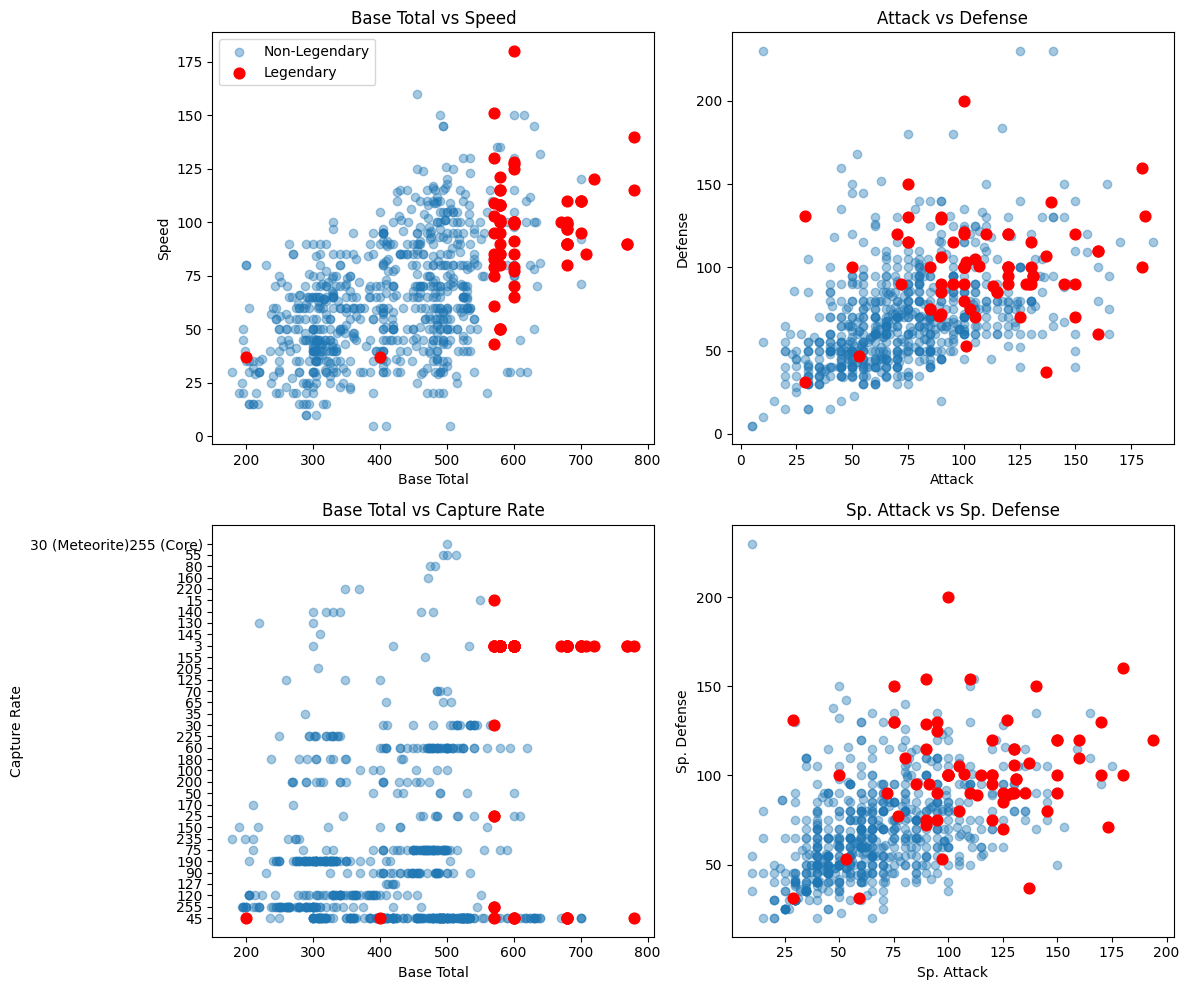

In [53]:
# Split data
legendary = df[df['is_legendary'] == 1]
non_legendary = df[df['is_legendary'] == 0]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

# 1. Base Total vs Speed
axes[0].scatter(non_legendary['base_total'], non_legendary['speed'], alpha=0.4, label='Non-Legendary')
axes[0].scatter(legendary['base_total'], legendary['speed'], color='red', s=60, label='Legendary')
axes[0].set_title('Base Total vs Speed')
axes[0].set_xlabel('Base Total')
axes[0].set_ylabel('Speed')
axes[0].legend()

# 2. Attack vs Defense
axes[1].scatter(non_legendary['attack'], non_legendary['defense'], alpha=0.4)
axes[1].scatter(legendary['attack'], legendary['defense'], color='red', s=60)
axes[1].set_title('Attack vs Defense')
axes[1].set_xlabel('Attack')
axes[1].set_ylabel('Defense')

# 3. Base Total vs Capture Rate
axes[2].scatter(non_legendary['base_total'], non_legendary['capture_rate'], alpha=0.4)
axes[2].scatter(legendary['base_total'], legendary['capture_rate'], color='red', s=60)
axes[2].set_title('Base Total vs Capture Rate')
axes[2].set_xlabel('Base Total')
axes[2].set_ylabel('Capture Rate')

# 4. Sp. Attack vs Sp. Defense
axes[3].scatter(non_legendary['sp_attack'], non_legendary['sp_defense'], alpha=0.4)
axes[3].scatter(legendary['sp_attack'], legendary['sp_defense'], color='red', s=60)
axes[3].set_title('Sp. Attack vs Sp. Defense')
axes[3].set_xlabel('Sp. Attack')
axes[3].set_ylabel('Sp. Defense')

plt.tight_layout()
plt.show()

### Preprocessing

The raw dataset needs several cleaning steps before it can be fed to a linear classifier:

- Drop free-text columns (`abilities`, `japanese_name`, `name`, `classfication`) that are not useful as features.
- Coerce `capture_rate` to numeric (it was stored as string).
- Impute missing values (`type2`, `percentage_male`, `height_m`, `weight_kg`) with sensible defaults.
- One-hot encode the `type1` and `type2` categorical variables.
- Standardize numeric features to zero mean and unit variance so that the LinearSVC is not dominated by large-scale features like `experience_growth`.

In [54]:
# Cleaning

# Drop useless columns
df = df.drop(columns=[
    "abilities",
    "japanese_name",
    "name",
    "classfication"
])

# Fix data type (capture_rate is string instead of int)
df["capture_rate"] = pd.to_numeric(df["capture_rate"], errors="coerce")

# Fill type2 missing data with None, fill percentage_male, height, weight with median
df["type2"] = df["type2"].fillna("None")
df["percentage_male"] = df["percentage_male"].fillna(df["percentage_male"].median())
df["height_m"] = df["height_m"].fillna(df["height_m"].median())
df["weight_kg"] = df["weight_kg"].fillna(df["weight_kg"].median())
df["capture_rate"] = df["capture_rate"].fillna(df["capture_rate"].median())

# Encode categorical variables (type1 and type2)
df = pd.get_dummies(df, columns=["type1", "type2"], drop_first=True)

In [55]:
# Define features and target variable 
# Target: Is the pokemon legendary or not?
X = df.drop(columns=["is_legendary"])
y = df["is_legendary"]

In [56]:
# Check no missing values left and shape
# We have 801 pokemons and 69 features and no missing values left

print("Any NaNs left:", np.isnan(X).sum().sum())
print("Shape of X:", X.shape)

Any NaNs left: 0
Shape of X: (801, 69)


In [57]:
# Scale numeric features to mean=0, std=1; convert boolean features to 0/1
numeric_cols = X.select_dtypes(include=['float64', 'int64']).columns
bool_cols = X.select_dtypes(include=['bool']).columns

X[bool_cols] = X[bool_cols].astype(int)

scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

print(f"Scaled {len(numeric_cols)} numeric columns, converted {len(bool_cols)} boolean columns")
print("Shape of X:", X.shape)

Scaled 34 numeric columns, converted 35 boolean columns
Shape of X: (801, 69)


### Train/Test Split

We split 70/30 stratified by the target class. Stratification matters here because legendary Pokémon make up only ~9% of the data — without it, a random split could under-represent the positive class in either fold and destabilize both training and evaluation.

In [58]:
# Train/test split (70/30, stratified by target class)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=11, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (560, 69), Test: (241, 69)


### Johnson-Lindenstrauss Bound

The JL lemma states that $n$ points in high-dimensional space can be projected into $k$ dimensions while approximately preserving pairwise distances, provided:

$$k \geq \frac{4 \ln(n)}{\varepsilon^2 / 2 - \varepsilon^3 / 3}$$

where $\varepsilon$ controls the distortion tolerance. For this dataset, the theoretical bound is far larger than the original 69 features.

In [59]:
# Johnson-Lindenstrauss bound
# This is only a theoretical distance-preservation bound/ worst-case theoretical guarantee, not a classification optimum
# If you want to preserve all pairwise distances between points with very small error (ε=0.1), then you may need a high dimension (5730 dimensions for 801 samples)
jl_bound = johnson_lindenstrauss_min_dim(n_samples=X.shape[0], eps=0.1)
print(f"Johnson-Lindenstrauss lower bound for eps=0.1: k >= {jl_bound} given n={X.shape[0]} samples")

Johnson-Lindenstrauss lower bound for eps=0.1: k >= 5730 given n=801 samples


In [60]:
# Class distribution in target variable 
# Majority-class baseline accuracy (~91%) for comparison 
# unbalanced classes (801 pokemons, 70 legendary → 731 non-legendary)
print(y.value_counts(normalize=True))

is_legendary
0    0.912609
1    0.087391
Name: proportion, dtype: float64


### Baseline and Random Projection Experiment

We first train a LinearSVC on the full 69-dimensional data to establish a baseline accuracy and F1-score. Then, for each target dimensionality $k$, we generate a sparse random projection matrix, project both train and test data, train a LinearSVC, and evaluate the metrics. The procedure is repeated over multiple realizations and averaged.

Because the classes are strongly imbalanced (~9% legendary), we report binary F1 on the positive class alongside accuracy — a classifier that always predicts "non-legendary" already reaches ~91% accuracy, so F1 is the more informative signal.

Dimensions are log-spaced so that we test more projections at low $k$ (where accuracy changes rapidly) and fewer at high $k$ (where it plateaus), reducing total computation time.

In [61]:
# Baseline model on full dimensionality
baseline_model = LinearSVC(max_iter=1000, random_state=42)
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

baseline_acc    = accuracy_score(y_test, baseline_pred)
baseline_f1     = f1_score(y_test, baseline_pred, zero_division=0)
baseline_recall = recall_score(y_test, baseline_pred, zero_division=0)
print(f"Baseline accuracy (d={X.shape[1]}): {baseline_acc:.4f}")
print(f"Baseline F1-score: {baseline_f1:.4f}")
print(f"Baseline recall:   {baseline_recall:.4f}")

# Random projection experiment (log-spaced dimensions)
# 100 realizations so the ensemble-size comparison can show 1, 10, 25, 50, 100 runs
realizations = 100
dims = make_dims(X.shape[1], n_points=15)
print(f"\nTested dimensions ({len(dims)}): {dims}")
print(f"Running {realizations} random projections per dimension...\n")

poke_results = run_rp_experiment(
    X_train, X_test, y_train, y_test, dims,
    realizations=realizations, max_iter=1000, f1_avg='binary'
)


Baseline accuracy (d=69): 0.9876
Baseline F1-score: 0.9231
Baseline recall:   0.8571

Tested dimensions (14): [ 2  3  4  5  7  9 11 15 19 25 32 41 53 69]
Running 100 random projections per dimension...

  k=   2:  acc = 0.9185 +/- 0.0128  |  F1 = 0.1204 +/- 0.2122  |  Recall = 0.0895 +/- 0.1795
  k=   3:  acc = 0.9194 +/- 0.0148  |  F1 = 0.1491 +/- 0.2262  |  Recall = 0.1105 +/- 0.1934
  k=   4:  acc = 0.9232 +/- 0.0181  |  F1 = 0.2346 +/- 0.2507  |  Recall = 0.1719 +/- 0.2110
  k=   5:  acc = 0.9316 +/- 0.0217  |  F1 = 0.3380 +/- 0.2889  |  Recall = 0.2605 +/- 0.2609
  k=   7:  acc = 0.9400 +/- 0.0213  |  F1 = 0.4812 +/- 0.2578  |  Recall = 0.3848 +/- 0.2520
  k=   9:  acc = 0.9479 +/- 0.0219  |  F1 = 0.5815 +/- 0.2395  |  Recall = 0.4867 +/- 0.2485
  k=  11:  acc = 0.9565 +/- 0.0240  |  F1 = 0.6693 +/- 0.2236  |  Recall = 0.5829 +/- 0.2519
  k=  15:  acc = 0.9668 +/- 0.0196  |  F1 = 0.7706 +/- 0.1595  |  Recall = 0.6962 +/- 0.1953
  k=  19:  acc = 0.9735 +/- 0.0152  |  F1 = 0.8298 +/

### Results

The plots show the averaged accuracy and F1-score (solid lines) with shaded $\pm 1\sigma$ bands indicating variability across random projections. The red dashed line is the baseline on the full 69-dimensional data. The bottom-right panel demonstrates why ensemble averaging produces a smoother, more reliable curve than a single random projection.

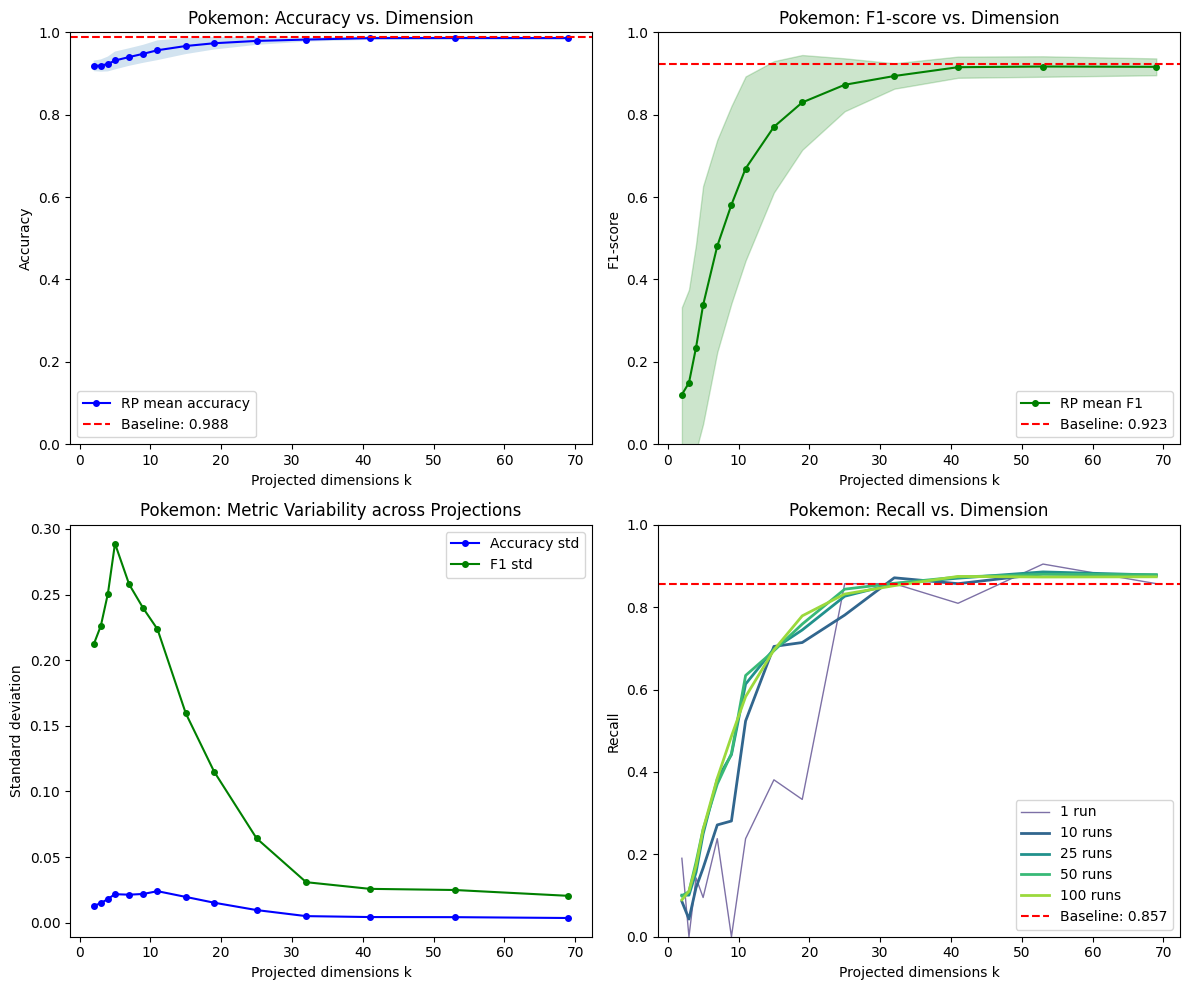

In [62]:
plot_rp_results(dims, poke_results, baseline_acc, baseline_f1,
                'Pokemon', realizations,
                ensemble_sizes=[1, 10, 25, 50, 100],
                baseline_recall=baseline_recall)


## 2. Fashion Dataset

**Dataset:**
- **Fashion-MNIST** (Zalando): 60,000 grayscale images (28×28) of clothing items, 10 classes

The dataset lives in 784-dimensional Euclidean space, making it well-suited for random projection analysis.

### Load and Explore

We load the Fashion-MNIST dataset from CSV. Each row is one image: the first column is the class label, the remaining 784 columns are pixel values (28x28 grayscale). We subsample to keep computation time reasonable.

In [63]:
# --- Fashion-MNIST ---
fashion_df = pd.read_csv("fashion-mnist_train.csv")
# Subsample to 5,000 for faster computation
fashion_df = fashion_df.sample(n=5000, random_state=42)
fashion_data = fashion_df.iloc[:, 1:].values   # 784 pixel columns
fashion_target = fashion_df.iloc[:, 0].values   # label column

fashion_labels = {0: "T-shirt/top", 1: "Trouser", 2: "Pullover", 3: "Dress",
                  4: "Coat", 5: "Sandal", 6: "Shirt", 7: "Sneaker",
                  8: "Bag", 9: "Ankle boot"}

print(f"Fashion-MNIST: {fashion_data.shape[0]} samples, {fashion_data.shape[1]} features, "
      f"{len(np.unique(fashion_target))} classes")

Fashion-MNIST: 5000 samples, 784 features, 10 classes


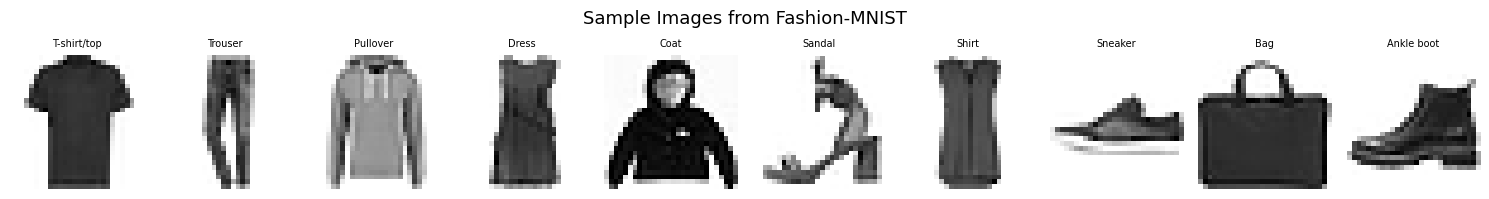

In [64]:
# Visualize sample images from the dataset
fig, axes = plt.subplots(1, 10, figsize=(15, 2))

# Fashion-MNIST samples (one per class)
for i in range(10):
    idx = np.where(fashion_target == i)[0][0]
    axes[i].imshow(fashion_data[idx].reshape(28, 28), cmap=plt.cm.gray_r, interpolation='nearest')
    axes[i].set_title(fashion_labels[i], fontsize=7)
    axes[i].axis('off')

plt.suptitle("Sample Images from Fashion-MNIST", fontsize=13)
plt.tight_layout()
plt.show()

### Johnson-Lindenstrauss Bound

The JL lemma states that $n$ points in high-dimensional space can be projected into $k$ dimensions while approximately preserving pairwise distances, provided:

$$k \geq \frac{4 \ln(n)}{\varepsilon^2 / 2 - \varepsilon^3 / 3}$$

where $\varepsilon$ controls the distortion tolerance. This bound is very conservative; in practice, good classification accuracy can be achieved with far fewer dimensions.

In [65]:
eps = 0.1
n_fashion = fashion_data.shape[0]

jl_fashion = johnson_lindenstrauss_min_dim(n_fashion, eps=eps)

print(f"JL minimum dimensions (eps={eps}):")
print(f"  Fashion-MNIST (n={n_fashion}): k >= {jl_fashion}")
print(f"\nOriginal dimensionality: d = 784")
print(f"The JL bound exceeds d=784, so the lemma does not guarantee preservation at eps=0.1.")
print(f"However, JL is a worst-case bound. Classification may still work well at much lower k.")

JL minimum dimensions (eps=0.1):
  Fashion-MNIST (n=5000): k >= 7300

Original dimensionality: d = 784
The JL bound exceeds d=784, so the lemma does not guarantee preservation at eps=0.1.
However, JL is a worst-case bound. Classification may still work well at much lower k.


### Train/Test Split and Baseline

We split 70/30, then train a LinearSVC on the full 784-dimensional data to establish a baseline accuracy and F1-score.

In [66]:
# Train/test split (70/30)
fash_trainX, fash_testX, fash_trainY, fash_testY = train_test_split(
    fashion_data, fashion_target, test_size=0.3, random_state=42
)

# Baseline model on full dimensionality
baseline_model = LinearSVC(max_iter=2000, random_state=42)
baseline_model.fit(fash_trainX, fash_trainY)
baseline_pred = baseline_model.predict(fash_testX)

baseline_fashion_acc    = accuracy_score(fash_testY, baseline_pred)
baseline_fashion_f1     = f1_score(fash_testY, baseline_pred, average='macro', zero_division=0)
baseline_fashion_recall = recall_score(fash_testY, baseline_pred, average='macro', zero_division=0)
print(f"Baseline accuracy (d={fashion_data.shape[1]}): {baseline_fashion_acc:.4f}")
print(f"Baseline macro F1-score: {baseline_fashion_f1:.4f}")
print(f"Baseline macro recall:   {baseline_fashion_recall:.4f}")


Baseline accuracy (d=784): 0.7320
Baseline macro F1-score: 0.7410
Baseline macro recall:   0.7369


### Random Projection Experiment

For each target dimensionality $k$ we generate a sparse random projection matrix, project both train and test data, train a LinearSVC, and evaluate accuracy and F1-score. We repeat this over multiple realizations and average the results.

Dimensions are log-spaced so that we test more projections at low $k$ (where accuracy changes rapidly) and fewer at high $k$ (where it plateaus), reducing total computation time.

In [67]:
# Random projection experiment (log-spaced dimensions)
realizations = 15
dims_fashion = make_dims(fashion_data.shape[1], n_points=20)
print(f"Tested dimensions ({len(dims_fashion)}): {dims_fashion}")
print(f"Running {realizations} random projections per dimension...\n")

fashion_results = run_rp_experiment(
    fash_trainX, fash_testX, fash_trainY, fash_testY, dims_fashion,
    realizations=realizations, max_iter=2000, f1_avg='macro'
)

Tested dimensions (19): [  2   3   5   7   9  13  18  24  33  46  63  86 118 162 223 305 418 572
 784]
Running 15 random projections per dimension...

  k=   2:  acc = 0.2735 +/- 0.0298  |  F1 = 0.1920 +/- 0.0310  |  Recall = 0.2770 +/- 0.0290
  k=   3:  acc = 0.3569 +/- 0.0262  |  F1 = 0.2939 +/- 0.0274  |  Recall = 0.3619 +/- 0.0279
  k=   5:  acc = 0.4596 +/- 0.0327  |  F1 = 0.4204 +/- 0.0384  |  Recall = 0.4633 +/- 0.0327
  k=   7:  acc = 0.5305 +/- 0.0289  |  F1 = 0.5008 +/- 0.0334  |  Recall = 0.5350 +/- 0.0286
  k=   9:  acc = 0.5735 +/- 0.0196  |  F1 = 0.5520 +/- 0.0210  |  Recall = 0.5796 +/- 0.0194
  k=  13:  acc = 0.6330 +/- 0.0194  |  F1 = 0.6166 +/- 0.0239  |  Recall = 0.6388 +/- 0.0186
  k=  18:  acc = 0.6780 +/- 0.0173  |  F1 = 0.6658 +/- 0.0192  |  Recall = 0.6846 +/- 0.0176
  k=  24:  acc = 0.7103 +/- 0.0114  |  F1 = 0.7011 +/- 0.0120  |  Recall = 0.7166 +/- 0.0110
  k=  33:  acc = 0.7376 +/- 0.0104  |  F1 = 0.7318 +/- 0.0125  |  Recall = 0.7438 +/- 0.0101
  k=  46:  a

### Results

The plots show the averaged accuracy and F1-score (solid lines) with shaded $\pm 1\sigma$ bands indicating variability across random projections. The red dashed line is the baseline on the full 784-dimensional data. The bottom-right panel demonstrates why ensemble averaging produces a smoother, more reliable curve than a single random projection.

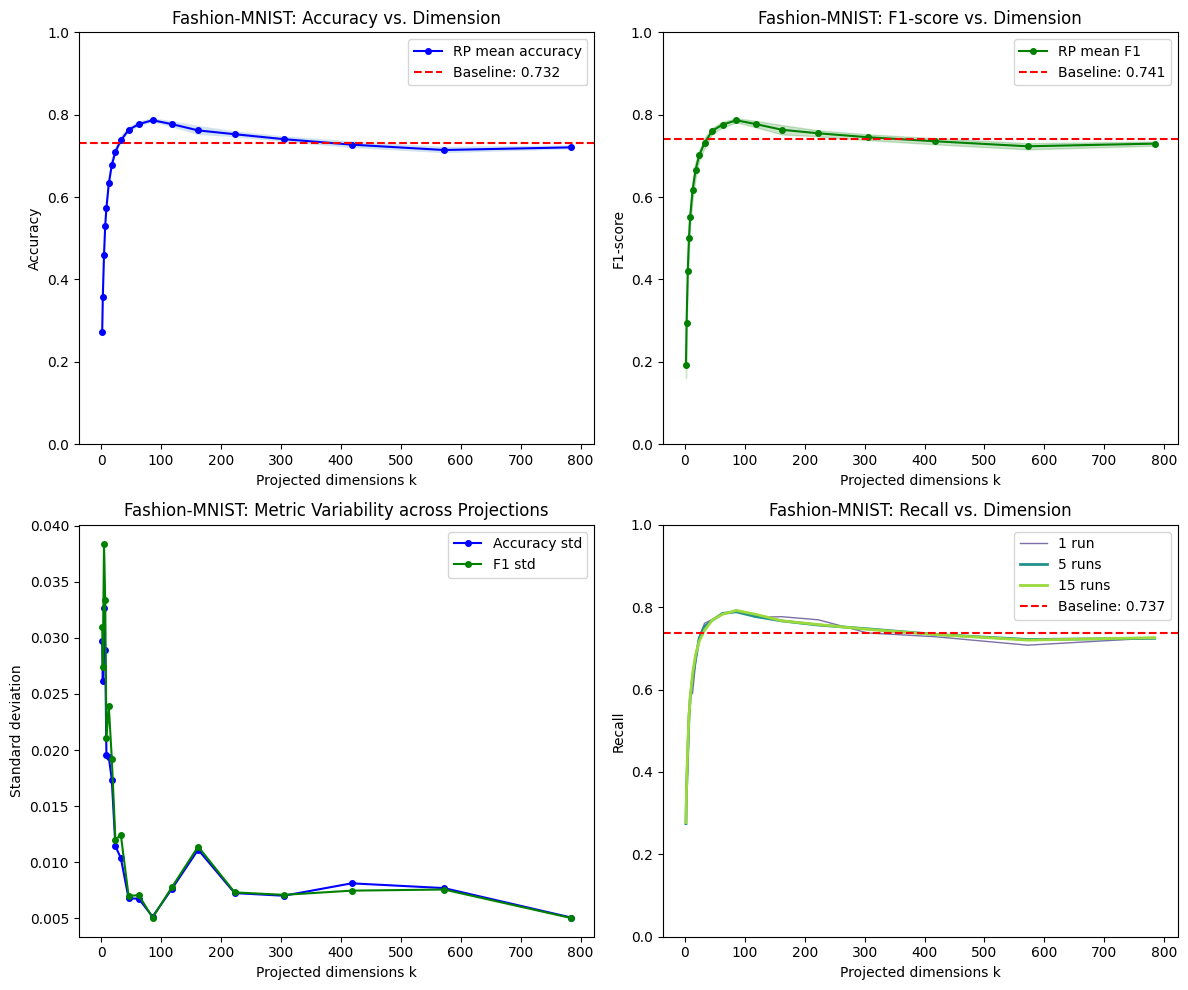

In [68]:
plot_rp_results(dims_fashion, fashion_results, baseline_fashion_acc, baseline_fashion_f1,
                'Fashion-MNIST', realizations,
                ensemble_sizes=[1, 5, 15],
                baseline_recall=baseline_fashion_recall)


## Take-Home Message

**Initial Question:**  
How does classification performance change when we reduce dimensionality using random projections?

---

### Findings

**1. Dimensionality reduction works in both datasets**  
Classification performance is largely preserved even after substantial reduction.  
- **Pokémon:** stabilizes around **25–30 dimensions (out of 69)**  
- **Fashion-MNIST:** improves and stabilizes around **50–100 dimensions (out of 784)**  
→ Indicates strong redundancy in the original feature space.

**2. Ensembling is essential for stability**  
A single random projection produces unstable results.  
Averaging over multiple projections:
- reduces variance  
- produces smooth, reliable performance curves  

**3. Random projections are especially effective when Euclidean distance is meaningful**  
- **Fashion-MNIST:** benefits strongly since pixel-space distances reflect similarity  
- **Pokémon:** performance is also well preserved despite non-geometric, engineered features  

→ Random projections work broadly, with particularly strong alignment for data with geometric structure.